## Agente Simple

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    google_api_key=GEMINI_API_KEY
)

r = llm.invoke("Explica RAG en un parrafo corto.")
r.content

/home/cristian94/ai-langchain/rag_cafe_contreras/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[{'type': 'text',
  'text': '**RAG** (Generación Aumentada por Recuperación) es una técnica que mejora la precisión de los modelos de inteligencia artificial al permitirles consultar fuentes de información externas y actualizadas antes de generar una respuesta. En lugar de depender únicamente de su entrenamiento previo, el sistema busca documentos relevantes en una base de datos específica, los utiliza como contexto y redacta una respuesta basada en esos datos reales, lo que reduce significativamente las alucinaciones y aumenta la fiabilidad de la información.',
  'extras': {'signature': 'EjQKMgERTTIP1VqP2kOYqgdUc4ceQFwf7eyCgZnk8aYv0s8kcwYndRg5sGXr2kLe2r99cVHe'}}]

## llm with structured output

In [21]:
SYSTEM_PROMPT = """
Eres un especialista en triaje y atención al cliente para Café Contreras.
Dado el mensaje del usuario, devuelve SÓLO un JSON con:\n
{\n
    "decision": "RAG" | "PEDIR_INFO" | "ABRIR_TICKET",\n
    "urgency": "BAJA" | "MEDIANA" | "ALTA",\n
}\n
Reglas:\n
- **RAG**: Preguntas cuya respuesta puede encontrarse en la base de conocimientos de Café Contreras, incluyendo:
    Historia de la Empresa, Misión, Visión y Valores, Organigrama y Responsabilidades, Código de Conducta, Políticas de Recursos Humanos (Basadas en la LFT de México), Beneficios para Empleados, Manual para Baristas, Manual para Cajeros, Manual para Supervisores, Manual para Gerentes, Procedimientos de Apertura, Procedimientos de Cierre, Limpieza y Sanitización, Seguridad Alimentaria, Uso de la Máquina de Espresso (La Marzocco Linea PB), Catálogo Selecto de Bebidas, Catálogo Selecto de Alimentos, Inventario Maestro, Marketing y Promociones, Atención al Cliente y Preguntas Frecuentes (FAQ), Casos Reales de Resolución de Conflictos, Glosario Cafetero Técnico. 
.\n
- **PEDIR_INFO**: Mensajes imprecisos, pedidos incompletos o consultas donde falta información clave para poder procesar la solicitud (Ej.: "Quiero reservar una mesa" - falta hora/personas, o "Quiero un café para llevar" - falta el tipo de café o tamaño).\n
- **ABRIR_TICKET**: Selecciona esta opción únicamente cuando la solicitud no pueda resolverse consultando la base de conocimientos y requiera que una persona real realice una acción, tome una decisión o dé seguimiento.

Incluye casos como:
- Problemas con pagos, cobros o facturación.
- Quejas o reclamaciones.
- Solicitudes de catering o eventos especiales.
- Cambios o excepciones que requieren autorización.
- Incidentes ocurridos en una sucursal.
- Solicitudes que requieren contactar al cliente posteriormente.
- Cuando el usuario solicita hablar con un agente humano.

NO selecciones ABRIR_TICKET si la pregunta puede responderse utilizando la documentación de la empresa, aunque trate sobre políticas internas, beneficios para empleados, menú, horarios, procedimientos, sucursales o reglamentos.
En esos casos selecciona RAG.

Al seleccionar ABRIR_TICKET, asume que un empleado humano recibirá posteriormente la solicitud para darle seguimiento.
"""

In [8]:
from typing import Literal, Dict
from pydantic import BaseModel

class TriajeOutput(BaseModel):
    decision: Literal["RAG", "PEDIR_INFO", "ABRIR_TICKET"]
    urgency: Literal["BAJA", "MEDIANA", "ALTA"]

In [9]:
from langchain_core.messages import SystemMessage, HumanMessage

llm_triajeOutput = llm.with_structured_output(TriajeOutput)

def triaje(mensaje: str) -> Dict:
    output: TriajeOutput = llm_triajeOutput.invoke(
        [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=mensaje)
        ]
    )

    return output.model_dump()

In [10]:
r = triaje("Hola, cual es el nombre de la compania?")
print(r)

{'decision': 'RAG', 'urgency': 'BAJA'}


In [11]:
preguntas_test = [
    "Hola, buenas tardes. ¿Me podrían decir si su Flat White lo preparan con el café origen Coatepec y si tiene leche de avena Oatly disponible en la sucursal de la Roma Norte?",
    "Hola, me gustaría apartar una mesa para este fin de semana en su sucursal de Coyoacán para festejar un cumpleaños.",
    "Hola, vengo saliendo de su sucursal de Polanco y revisando mi aplicación de BBVA veo que me pasaron dos veces la tarjeta. Me cobraron dos veces $170.00 pesos por mi pedido. Necesito que me ayuden a solucionarlo por favor.",
    "¡URGENTE! Acaba de ocurrir un accidente en su sucursal de Coyoacán. A un barista se le resbaló un Caffe Latte hirviendo y le cayó en el brazo a mi esposa, se está empezando a poner muy roja la piel. ¿Tienen botiquín o qué hacemos?",
    "Buenas tardes, quisiera que me coticen un servicio de barra de café móvil para una oficina. Seríamos varios invitados."
]

for q in preguntas_test:
    r = triaje(q)
    print(f"PREGUNTA: {q}")
    print(f"OUTPUT_TRIAJE: {r}")
    print("-----" * 5)

PREGUNTA: Hola, buenas tardes. ¿Me podrían decir si su Flat White lo preparan con el café origen Coatepec y si tiene leche de avena Oatly disponible en la sucursal de la Roma Norte?
OUTPUT_TRIAJE: {'decision': 'RAG', 'urgency': 'BAJA'}
-------------------------
PREGUNTA: Hola, me gustaría apartar una mesa para este fin de semana en su sucursal de Coyoacán para festejar un cumpleaños.
OUTPUT_TRIAJE: {'decision': 'PEDIR_INFO', 'urgency': 'MEDIANA'}
-------------------------
PREGUNTA: Hola, vengo saliendo de su sucursal de Polanco y revisando mi aplicación de BBVA veo que me pasaron dos veces la tarjeta. Me cobraron dos veces $170.00 pesos por mi pedido. Necesito que me ayuden a solucionarlo por favor.
OUTPUT_TRIAJE: {'decision': 'ABRIR_TICKET', 'urgency': 'ALTA'}
-------------------------
PREGUNTA: ¡URGENTE! Acaba de ocurrir un accidente en su sucursal de Coyoacán. A un barista se le resbaló un Caffe Latte hirviendo y le cayó en el brazo a mi esposa, se está empezando a poner muy roja la

### RAG (Retrieval Augmented Generation)
#### Carga, split, embedding de documentos

In [12]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

documentos = []

for doc in Path("../documents/").glob("*.pdf"):
    try:
        loader = PyMuPDFLoader(str(doc))
        documentos.extend(loader.load())
        print(f"Documento cargado: {doc.name}")
    except Exception as e:
        print(f"Error cargando documento: {doc.name}: {e}")

print(f"Documentos disponibles por ahora: {len(documentos)}")

/tmp/ipykernel_163098/180118597.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


Documento cargado: manual_operaciones_cafe_contreras_mexico.pdf
Documentos disponibles por ahora: 12


In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=200)
chunks = splitter.split_documents(documentos)

In [14]:
for chunk in chunks:
    print(chunk)
    print("-----" * 10)

page_content='MANUAL INTEGRAL DE OPERACIONES Y BASE
DE CONOCIMIENTOS
Café Contreras - Dataset Corporativo Adaptado para México (RAG & Agentes IA)
1. Historia de la Empresa
Fundada en 2018 en la Ciudad de México, Café Contreras nació de la visión de fusionar el arte del café de
especialidad mexicano con la optimización de procesos mediante inteligencia artificial. Los fundadores
identificaron que el sector gastronómico en México sufría de una alta rotación de personal y una pérdida
sistemática de consistencia en el servicio debido a manuales obsoletos y fragmentados. Durante el primer año de
operación, la empresa se centró en establecer relaciones directas con caficultores de las regiones de Coatepec
(Veracruz), Pluma Hidalgo (Oaxaca) y Jaltenango (Chiapas), asegurando un suministro ético y de calidad superior
(puntuaciones en taza superiores a 86 puntos SCA). En 2021, la empresa expandió su modelo a 5 sucursales en
zonas urbanas de alta densidad (Polanco, Roma Norte, Coyoacán, Guadalaj

In [15]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GEMINI_API_KEY
)

embedding_model2 = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

/tmp/ipykernel_163098/826697503.py:9: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model2 = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 911.18it/s]


In [16]:
from langchain_community.vectorstores import FAISS

vectorStore = FAISS.from_documents(chunks, embedding_model2)

retriever = vectorStore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.1, "k": 4}
)

In [17]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

prompt_rag = ChatPromptTemplate(
    [
        (
            "system",
            """
            Eres el especialista en Recursos Humanos de la empresa Café Contreras.
            Responde siempre utilizando exclusivamente la información del contexto que se te ha proporcionado.
            Si la respuesta a la pregunta del empleado no se encuentra en el contexto, responde únicamente 'No lo sé'.
            """,
        ),
        ("human", "Contexto: {context}\nPregunta del empleado: {input}"),
    ]
)

document_chain = create_stuff_documents_chain(llm, prompt_rag)

In [18]:
def busqueda_RAG(pregunta: str) -> Dict:
    related_docs = retriever.invoke(pregunta)

    # print(f"\nPregunta: {pregunta}")
    # print(f"Documentos recuperados: {len(related_docs)}\n")

    # for i, doc in enumerate(related_docs, 1):
    #     print(f"--- Documento {i} ---")
    #     print(doc.page_content[:400])
    #     print()

    if not related_docs:
        return {
            "respuesta": "No lo sé",
            "citaciones": [],
            "found_docs": False
        }
    
    respuesta = document_chain.invoke({
        "input": pregunta,
        "context": related_docs
    })

    return {
        "respuesta": respuesta,
        "citaciones": related_docs,
        "found_docs": True
    }

In [19]:
preguntas_test = [
    "Cuales son los beneficios para empleados?"
]

for q in preguntas_test:
    r = busqueda_RAG(q)
    print(f"PREGUNTA: {q}")
    print(f"OUTPUT_RAG: {r['respuesta']}")
    if r['found_docs']:
        for i, doc in enumerate(r['citaciones']):
            print(f"Doc {i + 1}:")
            print(f"Contenido: {doc.page_content}")
    print("-----" * 15)


PREGUNTA: Cuales son los beneficios para empleados?
OUTPUT_RAG: Los beneficios para empleados en Café Contreras son los siguientes:

*   **Prestaciones de Ley Superiores y Seguridad Social:** Alta inmediata ante el IMSS con el salario real percibido, aportaciones al INFONAVIT, aguinaldo de 20 días y prima vacacional del 35%.
*   **Consumo Interno Bonificado:** Derecho a 2 bebidas de especialidad gratuitas durante la jornada laboral y un descuento del 40% en bolsas de grano entero de café y alimentos del menú.
*   **Fondo de Certificación SCA:** Apoyo económico anual del 70% del costo para certificaciones oficiales de la Specialty Coffee Association (SCA) en los módulos de Barista Skills y Brewing, condicionado a una antigüedad mínima de 9 meses en la organización.
Doc 1:
Contenido: Clip o Verifone) y cobros SPEI/CoDi en presencia del Supervisor. Toda discrepancia numérica debe asentarse
en la bitácora electrónica corporativa.
Política de Descuentos y Devoluciones: Los descuentos estánd

## Structura en LangGraph

In [20]:
from typing import TypedDict, Optional, Any, Literal, NotRequired

class Ticket(TypedDict):
    id: str
    status: Literal["OPEN", "IN_PROGRESS", "CLOSED"]
    urgency: Literal["BAJA", "MEDIANA", "ALTA"]
    description: str
    
class AgentState(TypedDict):
    pregunta: str
    triaje: Optional[dict]
    respuesta: Optional[str]
    citaciones: Optional[str]
    rag_success: bool
    final_action: Optional[str]
    ticket: NotRequired[Ticket]


# nodos

In [23]:
def node_triaje(state: AgentState) -> dict[str, Any]:
    print("=== NODE_TRIAJE ===")

    return {
        "triaje": triaje(state["pregunta"])
    }

In [24]:
def node_rag(state: AgentState) -> dict[str, Any]:
    print("=== Node_RAG ===")

    response = busqueda_RAG(state['pregunta'])

    update: AgentState = {
        "respuesta": response['respuesta'],
        "citaciones": response['citaciones'],
        "rag_success": response['found_docs']
    }

    if response['found_docs']:
        update['final_action'] = "RAG"

        return update

In [73]:
from uuid import uuid4

def node_open_ticket(state: AgentState) -> dict[str, Any]:
    print("=== Node_open_ticket ===")

    triaje_response = state['triaje']

    ticket = {
        "id": uuid4(),
        "status": "OPEN",
        "urgency": triaje_response['urgency'],
        "description": state['pregunta']
    }

    return {
        "ticket": ticket
    }


In [74]:
def edge_triaje_decision(state: AgentState) -> str:
    print("=== edge_triaje_decision ===")

    triaje_response = state['triaje']
    if triaje_response['decision'] == "RAG":
        return "RAG"
    elif triaje_response['decision'] == "ABRIR_TICKET":
        return "ticket"
    else:
        return "END"

In [75]:
def node_final(state: AgentState):
    print("=== Node final ===")

    return {
        "output": {
            "respuesta": state.get("respuesta"),
            "citaciones": state.get("citaciones"),
            "ticket": state.get("ticket"),
            "rag_success": state.get("rag_success")
        }
    }

## Graph Builder

In [76]:
from langgraph.graph import START,END, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("triaje", node_triaje)
workflow.add_node("RAG", node_rag)
workflow.add_node("ticket", node_open_ticket)
workflow.add_node("final_response", node_final)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", edge_triaje_decision, {
    "RAG": "RAG",
    "ticket": "ticket",
    "END": END
})

workflow.add_edge("RAG", END)
workflow.add_edge("ticket", "final_response")
workflow.add_edge("final_response", END)

graph = workflow.compile()

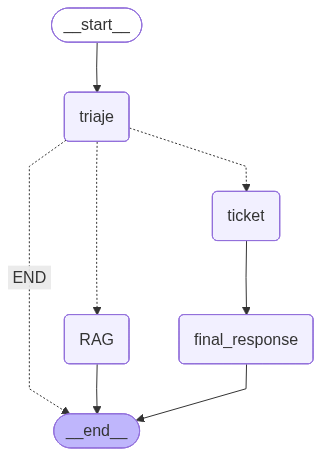

In [77]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Testing Ground

In [78]:
preguntas = [
    "Cuales son los beneficios para empleados?",
    "Me gustaria pedir informacion sobre el servicio de catering para 200 personas"
    ]



for q in preguntas:
    r = graph.invoke({"pregunta": q})
    print(f"PREGUNTA: {q}")
    print(f"DECISION: {r['triaje']}")
    print(f"RESPUESTA: {r}")

    print(f"FINAL: {r}")

=== NODE_TRIAJE ===
=== edge_triaje_decision ===
=== Node_RAG ===
PREGUNTA: Cuales son los beneficios para empleados?
DECISION: {'decision': 'RAG', 'urgency': 'BAJA'}
RESPUESTA: {'pregunta': 'Cuales son los beneficios para empleados?', 'triaje': {'decision': 'RAG', 'urgency': 'BAJA'}, 'respuesta': 'Los beneficios para empleados en Café Contreras son los siguientes:\n\n*   **Prestaciones de Ley Superiores y Seguridad Social:** Alta inmediata ante el IMSS con el salario real percibido, aportaciones al INFONAVIT, aguinaldo de 20 días y prima vacacional del 35%.\n*   **Consumo Interno Bonificado:** Derecho a 2 bebidas de especialidad gratuitas durante la jornada laboral y un descuento del 40% en bolsas de grano entero de café y alimentos del menú.\n*   **Fondo de Certificación SCA:** Apoyo económico anual del 70% del costo para certificaciones oficiales de la Specialty Coffee Association (SCA) en los módulos de Barista Skills y Brewing, condicionado a una antigüedad mínima de 9 meses en la